# 第 5 周 a｜生存分析入门：删失与 Kaplan-Meier 曲线

> **本周怎么学**：先学这份精讲，再做 `w05b_survival_and_censoring.ipynb`（工程实践：在训练集上用项目自己实现的 KM，比较"事件比例"与 1 − KM(5)）。

**这一节学什么**
- 为什么需要生存分析：随访时间和**删失**
- 用 **Kaplan-Meier（KM）法**估计累积发病率，画带**风险人数表**的 KM 图
- 用 **log-rank 检验**比较两组或多组曲线

**用到的数据**：Data Asset 1 的全部 5 万人。精讲篇重在理解概念，不做训练 / 验证 / 测试划分；划分放在工程篇（b）里学。

**前置**：第 1–2 周（随访时间、删失、人年发病率）

In [1]:
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test, proportional_hazard_test
from lifelines.utils import concordance_index

from pathlib import Path
import sys
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "run.py").exists())  # 向上找项目根目录
sys.path.insert(0, str(ROOT))

from primecvd import paths                 # 数据与输出路径（primecvd/paths.py）
from primecvd import pubplot as pp         # 顶刊风格作图工具箱（值得通读：primecvd/pubplot.py）
pp.setup()

T_MAX = 6                         # KM 图只画到第 6 年：之后仍在随访的人不到 2%，曲线不可信
TIMES = [0, 1, 2, 3, 4, 5, 6]     # 风险人数表的时间点

df = pd.read_csv(paths.ASSET1)
print(df.shape)

(50000, 12)


## 1. 为什么需要生存分析？

回顾第 1 周 a：每个人的随访时间不同，而且很多人是**删失**的（到随访结束都没发病）。

| 做法 | 问题 |
|---|---|
| 只比较"发病比例"（logistic 回归） | 忽略了随访时间，观察 1 年和 7 年的人被同等对待 |
| 把删失的人删掉 | 丢掉大量信息，而且留下的人偏向"发病者"，结果有偏 |
| **生存分析** | ✅ 同时利用"是否发病"和"多久发病"，并正确处理删失 |

生存分析的两个主力工具：
- **Kaplan-Meier**：描述性的，估计"随时间推移，有多少比例的人发病"
- **Cox 回归**：多变量模型，估计每个因素的**风险比（Hazard Ratio, HR）**

## 2. Kaplan-Meier：整个队列的累积发病率

KM 法在每个事件发生的时间点，计算"此刻仍在观察中的人里，有多少比例发病"，再把这些比例连乘起来，得到生存概率 S(t)。**累积发病率 = 1 − S(t)**，对心血管病来说这个指标更直观。

In [2]:
kmf = KaplanMeierFitter()
kmf.fit(df["cvd_time"], event_observed=df["cvd_event"], label="全队列")

for t in [1, 3, 5]:
    print(f"{t} 年累积发病率：{(1 - kmf.predict(t)) * 100:.2f}%")

1 年累积发病率：0.98%
3 年累积发病率：2.69%
5 年累积发病率：4.05%


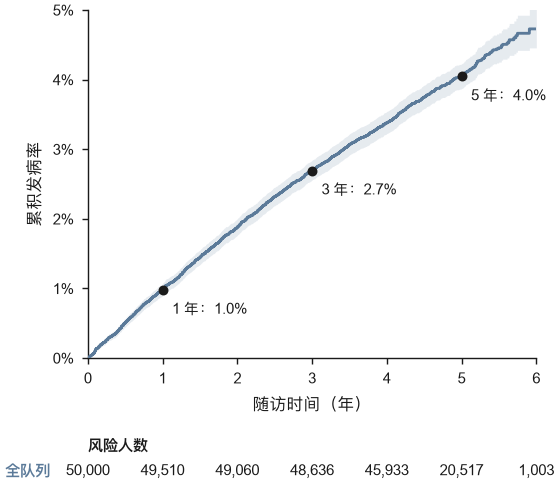

In [3]:
fig, ax, ax_tab = pp.km_figure(width_mm=pp.SINGLE, curve_mm=52, n_groups=1, left_mm=18)
kmf_all = pp.km_curve(ax, df["cvd_time"], df["cvd_event"], "全队列", pp.NEUTRAL, t_max=T_MAX)
for t in [1, 3, 5]:                                  # 标出正文里会引用的几个关键数字
    r = 1 - kmf_all.predict(t)
    ax.plot(t, r, "o", ms=3.2, color=pp.INK, zorder=4)
    ax.annotate(f"{t} 年：{r:.1%}", (t, r), xytext=(4, -5), textcoords="offset points",
                ha="left", va="top", fontsize=6.2)
ax.set_xlim(0, T_MAX); ax.set_xticks(TIMES)
ax.set_ylim(0, 0.05); pp.percent_axis(ax)
ax.set_xlabel("随访时间（年）"); ax.set_ylabel("累积发病率")
pp.risk_table(ax_tab, [kmf_all], ["全队列"], [pp.NEUTRAL], TIMES)
pp.save(fig, "03_km_overall")
plt.show()

全队列 5 年累积发病率约 4%。看下方的风险人数表：第 5 年还有约 2 万人，第 6 年只剩约 1,000 人，所以曲线末端的置信区间明显变宽。

🎨 **设计要点**
- **画"累积发病率"（从 0 往上升），而不是"生存率"（从 100% 往下降）**。事件率只有几个百分点时，生存曲线挤在 95%–100% 之间，几乎看不出变化。NEJM 等期刊的心血管试验普遍画累积发病率
- **纵轴只画到 5%**：这里是按数据范围设定的坐标，不是在夸大差异。线图用"位置"表示数值，不要求从 0 开始画满
- **截断在第 6 年**：随访人数太少的尾部，曲线只是噪声，不画反而更诚实
- **单栏宽 89 mm**：只有一条曲线，没必要占满双栏

> **图 5｜全队列 CVD 累积发病率（Kaplan-Meier 法）。** 阴影为 95% CI，下方为各时间点的风险人数。

## 3. KM 分组比较：糖尿病 vs 非糖尿病

分组各拟合一条 KM 曲线，再用 **log-rank 检验**判断两条曲线是否有显著差异。

图下方的 **"风险人数表"（number at risk）** 是临床论文 KM 图的标配，它告诉读者在每个时间点还有多少人在被观察。表格由 `pp.risk_table()` 画出，可以打开 `pubplot.py` 看看它是怎么和曲线对齐的。

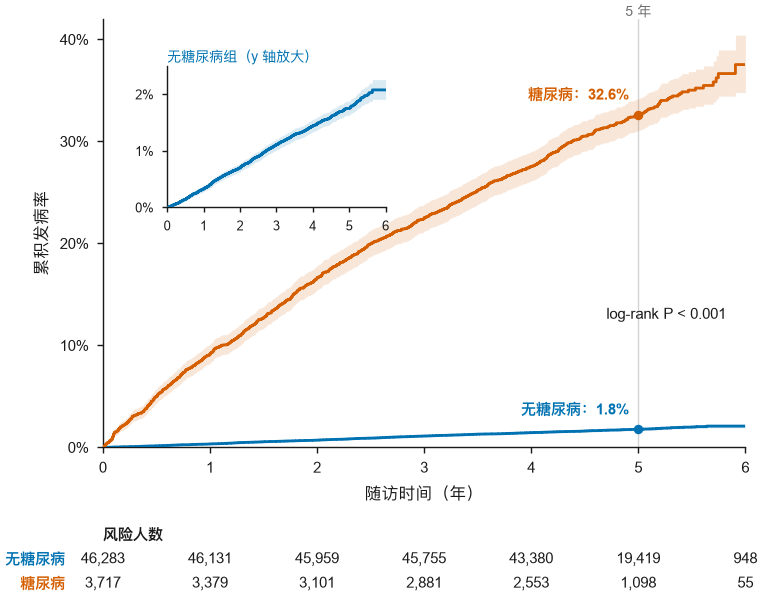

In [4]:
fig, ax, ax_tab = pp.km_figure(width_mm=pp.ONE_HALF, curve_mm=64, n_groups=2)
groups = [(0, "无糖尿病", pp.REFERENCE), (1, "糖尿病", pp.EXPOSED)]
fitters = []
for value, label, color in groups:
    sub = df[df["diabetes"] == value]
    fitters.append(pp.km_curve(ax, sub["cvd_time"], sub["cvd_event"], label, color, t_max=T_MAX))

# 在第 5 年处直接标注两组的累积发病率（直接标注，代替图例）
ax.axvline(5, color=pp.LIGHT, lw=0.6, zorder=0)
ax.text(5, 1.0, "5 年", transform=ax.get_xaxis_transform(), ha="center", va="bottom",
        fontsize=6, color=pp.GREY)
for kmf, (_, label, color) in zip(fitters, groups):
    r5 = 1 - kmf.predict(5)
    ax.plot(5, r5, "o", ms=3, color=color, zorder=5)
    ax.annotate(f"{label}：{r5:.1%}", (5, r5), xytext=(-4, 5), textcoords="offset points",
                ha="right", va="bottom", fontsize=6.5, color=color, fontweight="bold")

dm, no_dm = df[df["diabetes"] == 1], df[df["diabetes"] == 0]
p_lr = logrank_test(dm["cvd_time"], no_dm["cvd_time"], dm["cvd_event"], no_dm["cvd_event"]).p_value
ax.text(0.97, 0.3, f"log-rank {pp.format_p(p_lr)}", transform=ax.transAxes, ha="right", fontsize=6.5)
ax.set_xlim(0, T_MAX); ax.set_xticks(TIMES)
ax.set_ylim(0, 0.42); ax.set_yticks([0, 0.1, 0.2, 0.3, 0.4]); pp.percent_axis(ax)
ax.set_xlabel("随访时间（年）"); ax.set_ylabel("累积发病率")

# 嵌入放大图：事件率低的组在主图里被"压扁"了，用同一条时间轴、放大的 y 轴单独再画一次
ins = ax.inset_axes([0.1, 0.56, 0.34, 0.33])
pp.km_curve(ins, no_dm["cvd_time"], no_dm["cvd_event"], "无糖尿病", pp.REFERENCE, t_max=T_MAX)
ins.set_xlim(0, T_MAX); ins.set_xticks(TIMES)
ins.set_ylim(0, 0.025); ins.set_yticks([0, 0.01, 0.02]); pp.percent_axis(ins)
ins.tick_params(labelsize=5.5, length=2)
ins.set_title("无糖尿病组（y 轴放大）", fontsize=6, fontweight="normal", color=pp.REFERENCE, pad=2)

pp.risk_table(ax_tab, fitters, [g[1] for g in groups], [g[2] for g in groups], TIMES)
pp.save(fig, "03_km_by_diabetes")
plt.show()

🎨 **设计要点**（这张图集中了医学期刊 KM 图的几个标准做法）
- **风险人数表和曲线共用同一条时间轴，上下严格对齐**；组名用曲线的颜色，读者不需要图例
- **嵌入放大图（inset）**：糖尿病组的曲线升到 30% 以上，无糖尿病组就被压成贴近 0 的一条线。NEJM 常用的办法是在空白处嵌一个放大 y 轴的小图，两组都能看清
- **5 年处的直接标注**：正文最常引用的数字（5 年累积发病率）直接写在图上
- **配色语义不变**：暴露组（糖尿病）朱红，参照组蓝色，和第 1 周 a 的图 2 一致
- **置信区间用浅色阴影**：透明度 0.15，看得见但不喧宾夺主

> **图 6｜按糖尿病状态分组的 CVD 累积发病率。** 阴影为 95% CI；嵌入图放大显示无糖尿病组。P 值来自 log-rank 检验。

In [5]:
dm, no_dm = df[df["diabetes"] == 1], df[df["diabetes"] == 0]
result = logrank_test(dm["cvd_time"], no_dm["cvd_time"], dm["cvd_event"], no_dm["cvd_event"])
print(f"log-rank 检验：卡方 = {result.test_statistic:.1f}，P {'< 0.001' if result.p_value < 0.001 else '= ' + format(result.p_value, '.3f')}")

log-rank 检验：卡方 = 9723.3，P < 0.001


两条曲线差别巨大：糖尿病组 5 年累积发病率约三分之一。log-rank 检验的 P 值极小。

但这仍然是**未调整**的比较：糖尿病患者更老、血压更高。要同时考虑多个因素，就需要 Cox 回归。

## 4. KM 分组比较：IRSD 五分位

IRSD 是有序变量，这里用**同一种蓝色由深到浅**表示 1（最贫困）到 5（最富裕），而不是 5 种不同的颜色。

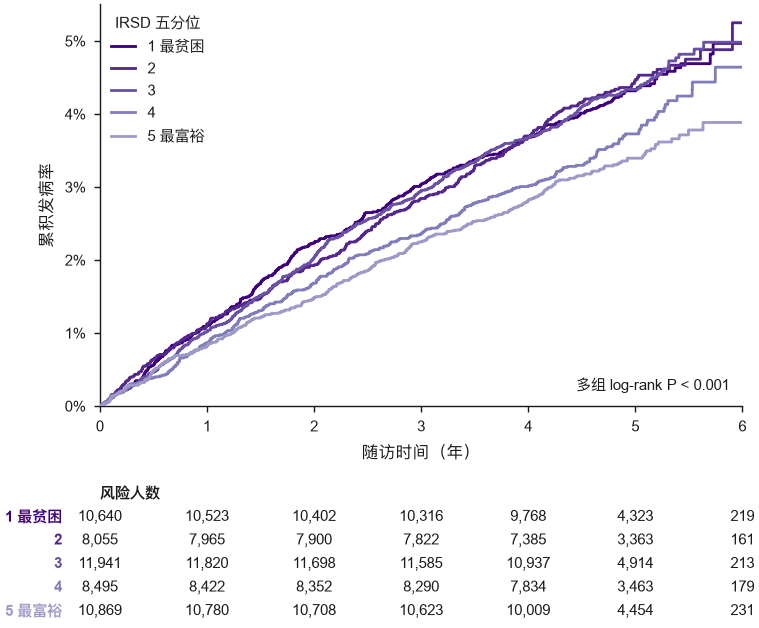

多组 log-rank 检验：P = 0.0003


In [6]:
fig, ax, ax_tab = pp.km_figure(width_mm=pp.ONE_HALF, curve_mm=60, n_groups=5)
names = {1: "1 最贫困", 2: "2", 3: "3", 4: "4", 5: "5 最富裕"}
fitters = []
for q in [1, 2, 3, 4, 5]:
    sub = df[df["IRSD_quintile"] == q]
    # 五条曲线不画置信区间：五片阴影叠在一起只会糊成一团
    fitters.append(pp.km_curve(ax, sub["cvd_time"], sub["cvd_event"], names[q], pp.IRSD[q],
                               t_max=T_MAX, ci=False))
ax.legend(title="IRSD 五分位", loc="upper left")
result = multivariate_logrank_test(df["cvd_time"], df["IRSD_quintile"], df["cvd_event"])
ax.text(0.98, 0.04, f"多组 log-rank {pp.format_p(result.p_value)}", transform=ax.transAxes,
        ha="right", fontsize=6.5)
ax.set_xlim(0, T_MAX); ax.set_xticks(TIMES)
ax.set_ylim(0, 0.055); pp.percent_axis(ax)
ax.set_xlabel("随访时间（年）"); ax.set_ylabel("累积发病率")
pp.risk_table(ax_tab, fitters, list(names.values()), list(pp.IRSD.values()), TIMES)
pp.save(fig, "03_km_by_irsd")
plt.show()
print(f"多组 log-rank 检验：P = {result.p_value:.4f}")

五条曲线靠得很近，但 4、5 组（较富裕）明显更低，和第 2 周 a 的发现一致。

🎨 **设计要点**
- **五组以上就不画置信区间阴影**，否则会糊成一片。需要看不确定性时，改用 Cox 模型的 HR 和 CI（见森林图）
- **颜色和第 2 周 a 的图 3 完全一致**（深紫 = 最贫困），读者在两张图之间来回看时不需要重新学颜色
- 这里曲线靠得太近，没法直接标注，所以用图例；图例放在左上角的空白处，不压数据

> **图 7｜按 IRSD 五分位分组的 CVD 累积发病率。** P 值来自多组 log-rank 检验。

## 小结

| 方法 | 回答的问题 | lifelines 代码 |
|---|---|---|
| Kaplan-Meier | 随时间推移有多少人发病？ | `KaplanMeierFitter().fit(T, E)` |
| log-rank 检验 | 两组 / 多组曲线有差异吗？ | `logrank_test`、`multivariate_logrank_test` |
| 风险人数表 | 每个时间点还有多少人在被观察？ | `pp.risk_table()` |

**核心概念**：删失、累积发病率 = 1 − 生存率、风险集、log-rank 检验、为什么要截断曲线尾部

## 练习

1. 仿照第 3 节，用 `pp.km_figure()`、`pp.km_curve()` 和 `pp.risk_table()` 画一张按吸烟状态分组的 KM 累积发病率图（颜色用 `pp.SMOKING["non"]` 等），并做多组 log-rank 检验。
2. 把 `T_MAX` 改成 7.3（数据里最长的随访），重画图 6。曲线尾部发生了什么？看风险人数表，解释原因。
3. 比较 `df["cvd_event"].mean()`（事件比例）和 `1 - kmf.predict(5)`（5 年累积发病率）。这份数据里两者很接近，什么情况下它们会差很多？